# 🌟 **A Hybrid SVM-RF Machine Learning Framework for Dual-Plane DDoS Detection and Mitigation in Software-Defined Networks** 🌟


In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.pipeline import make_pipeline
import joblib
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# Load the dataset
df = pd.read_csv('balanced_cleaned_dataset.csv')

# Display the first few rows
print(df.head())

# Check for missing values
print(df.isnull().sum())


       id  duration protocol_type  service flag  src_bytes  dst_bytes  land  \
0    8656         0          icmp    eco_i   SF         18          0     0   
1  107849         0           tcp    login   S0          0          0     0   
2    3238         0           tcp     http   SF        306       2239     0   
3   48274         0           tcp   domain   S0          0          0     0   
4   96195         0           tcp  private  REJ          0          0     0   

   wrong_fragment  urgent  ...  dst_host_srv_count  dst_host_same_srv_rate  \
0               0       0  ...                  57                    1.00   
1               0       0  ...                   3                    0.01   
2               0       0  ...                 225                    0.88   
3               0       0  ...                  10                    0.04   
4               0       0  ...                  12                    0.10   

   dst_host_diff_srv_rate  dst_host_same_src_port_rate  

In [3]:
# Dropping any rows with missing values (if needed)
df.dropna(inplace=True)

# Remove duplicate records
df.drop_duplicates(inplace=True)

# Remove any irrelevant columns (if any) - Example:
# df = df.drop(columns=['Irrelevant_Column'])


In [4]:
# Label encoding for the target variable (class)
le = LabelEncoder()
df['class'] = le.fit_transform(df['class'])

# Save the label encoder to reuse later
joblib.dump(le, 'label_encoder.pkl')


['label_encoder.pkl']

In [5]:
# One-Hot Encoding for categorical columns
df_encoded = pd.get_dummies(df, drop_first=True)  # drop_first=True avoids multicollinearity

# Split the data into features (X) and target variable (y)
X = df_encoded.drop(columns=['class'])
y = df_encoded['class']


In [40]:
# Feature selection using SelectKBest with f_classif (ANOVA F-value)
selector = SelectKBest(score_func=f_classif, k=20)
X_new = selector.fit_transform(X, y)

# Get the top 20 selected features
selected_features = X.columns[selector.get_support()]
print(f"Top 20 Features: {selected_features}")


Top 20 Features: Index(['logged_in', 'count', 'serror_rate', 'srv_serror_rate', 'rerror_rate',
       'srv_rerror_rate', 'same_srv_rate', 'dst_host_count',
       'dst_host_srv_count', 'dst_host_same_srv_rate',
       'dst_host_diff_srv_rate', 'dst_host_serror_rate',
       'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
       'dst_host_srv_rerror_rate', 'service_domain_u', 'service_http',
       'service_private', 'flag_S0', 'flag_SF'],
      dtype='object')


c:\Users\1256\.conda\envs\myenv\lib\site-packages\sklearn\feature_selection\_univariate_selection.py:112: UserWarning: Features [ 6 17 18] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\Users\1256\.conda\envs\myenv\lib\site-packages\sklearn\feature_selection\_univariate_selection.py:113: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


In [39]:
# Get the top 20 selected features
selected_features = X.columns[selector.get_support()]
print(f"Top 20 Features: {selected_features}")

Top 20 Features: Index(['logged_in', 'count', 'serror_rate', 'srv_serror_rate', 'rerror_rate',
       'srv_rerror_rate', 'same_srv_rate', 'dst_host_count',
       'dst_host_srv_count', 'dst_host_same_srv_rate',
       'dst_host_diff_srv_rate', 'dst_host_serror_rate',
       'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
       'dst_host_srv_rerror_rate', 'service_domain_u', 'service_http',
       'service_private', 'flag_S0', 'flag_SF'],
      dtype='object')


# 📊 **Class Distribution in the Target Variable**

Understanding the distribution of the target variable (class) is crucial to ensure that the dataset is balanced or to identify any class imbalance issues that may affect model performance.

### **Class Distribution Plot:**

The plot below visualizes the distribution of the target variable, showing how the classes are distributed in our dataset. A balanced dataset typically has similar frequencies for each class, whereas an imbalanced dataset may have certain classes with significantly more or fewer samples.


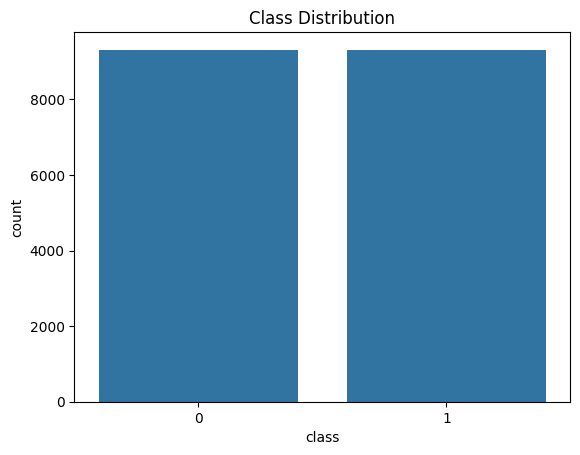

In [8]:
# Distribution of classes in the target variable
sns.countplot(x='class', data=df)
plt.title('Class Distribution')
plt.show()




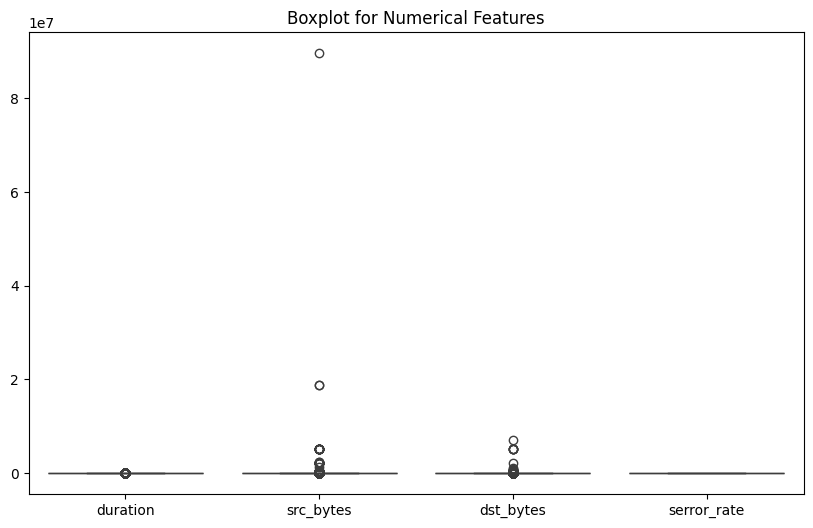

In [9]:
# Boxplot to detect outliers in numerical features
plt.figure(figsize=(10, 6))
sns.boxplot(data=df[['duration', 'src_bytes', 'dst_bytes', 'serror_rate']])
plt.title('Boxplot for Numerical Features')
plt.show()


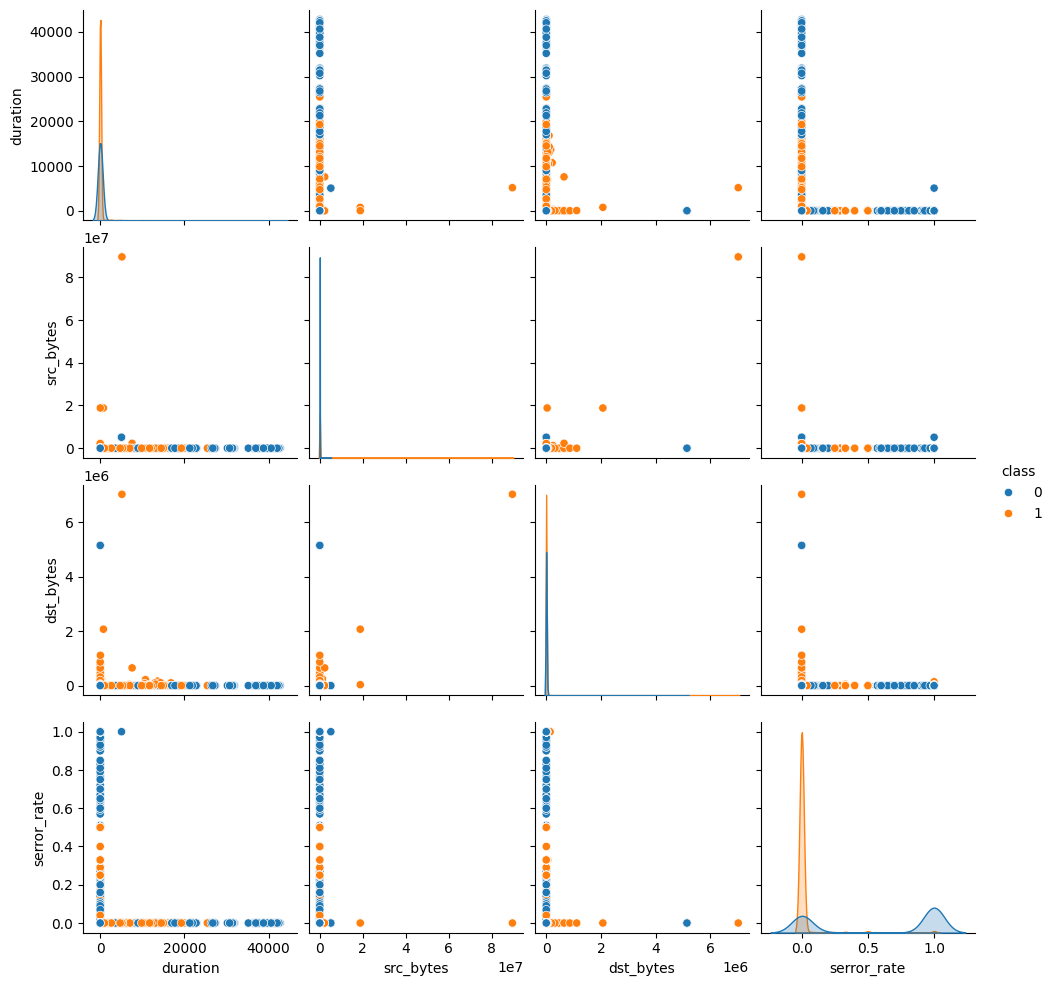

In [10]:
# Pairplot colored by class
sns.pairplot(df[['duration', 'src_bytes', 'dst_bytes', 'serror_rate', 'class']], hue='class')
plt.show()


In [11]:
# Split data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X_new, y, test_size=0.2, random_state=42)


# 🤖 **Model Initialization and Training**

In this section, we initialize and train two powerful machine learning models:
1. **Support Vector Machine (SVM)** with a **linear kernel**.
2. **Random Forest (RF)** with 100 estimators.

### **Step 1: Initialize the Models**

We begin by initializing the models with their respective hyperparameters. The **SVM model** is configured with a **linear kernel**, and the **Random Forest** model is set with 100 trees (estimators). These models are known for their effectiveness in classification tasks and are widely used due to their versatility.

```python
# Initialize models
svm_model = SVC(kernel='linear', random_state=42)  # Support Vector Machine with linear kernel
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)  # Random Forest with 100 estimators


In [14]:
# Initialize models
svm_model = SVC(kernel='linear', random_state=42)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Fit models on the training data
svm_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)

# Make predictions with the trained models
svm_pred = svm_model.predict(X_test)
rf_pred = rf_model.predict(X_test)

# For the hybrid model (SVM + RandomForest)
# Using averaging for hybrid predictions
final_pred = (svm_pred + rf_pred) // 2  # Simple averaging for binary classification


# 📊 **Model Performance Evaluation**

In this section, we evaluate the performance of the three models: **SVM**, **Random Forest (RF)**, and **Hybrid Model** using multiple metrics such as **Confusion Matrix**, **Precision**, **Recall**, and **F1-score**.

## 1️⃣ **Confusion Matrix Visualizations**

The **Confusion Matrix** is a great tool to evaluate classification results. It shows the **true positives (TP)**, **false positives (FP)**, **false negatives (FN)**, and **true negatives (TN)** for each class.

### **SVM Confusion Matrix**
The confusion matrix for the **Support Vector Machine (SVM)** model is displayed below, showing the number of correct and incorrect predictions for each class.


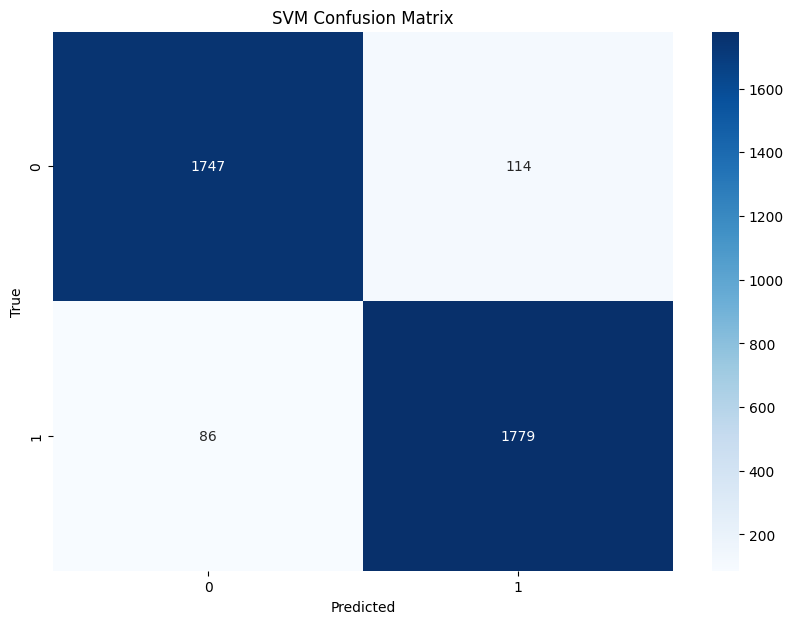

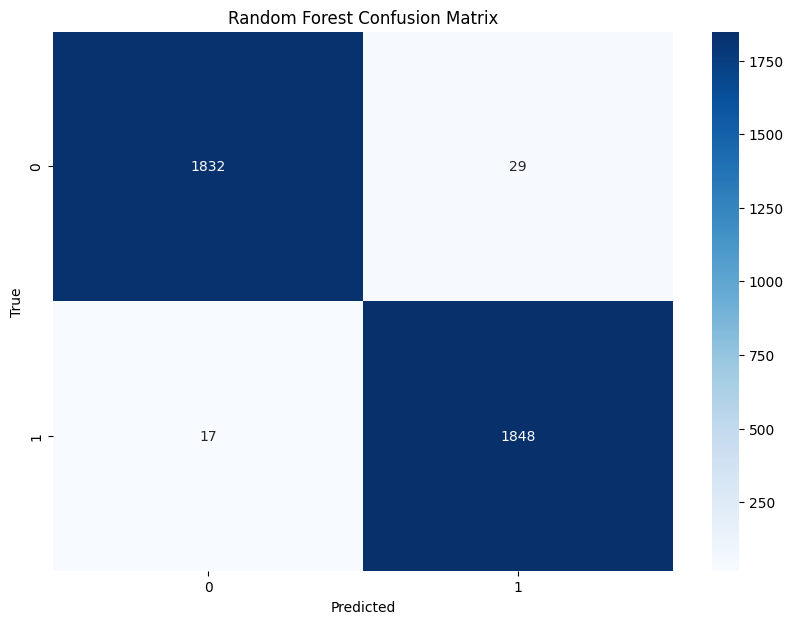

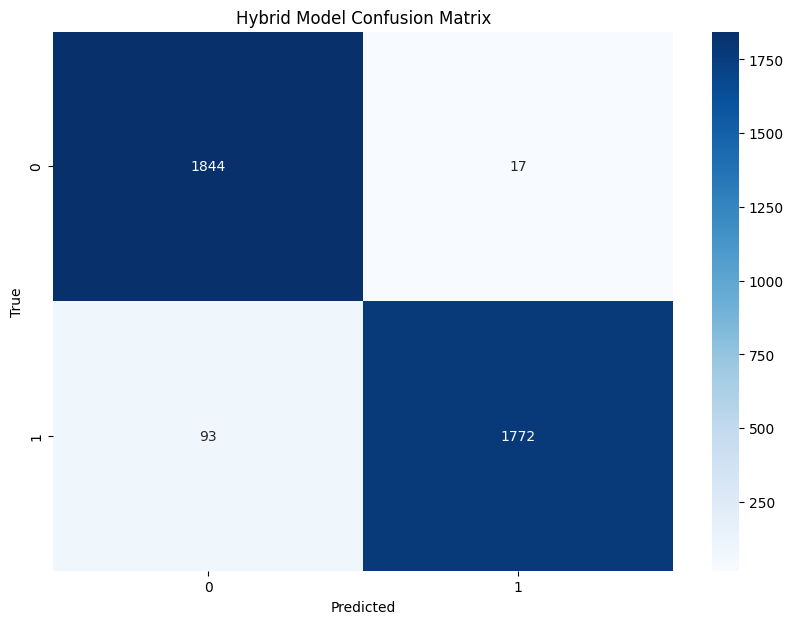


SVM Classification Report:
              precision    recall  f1-score      support
0              0.953082  0.938743  0.945858  1861.000000
1              0.939778  0.953887  0.946780  1865.000000
accuracy       0.946323  0.946323  0.946323     0.946323
macro avg      0.946430  0.946315  0.946319  3726.000000
weighted avg   0.946423  0.946323  0.946320  3726.000000

Random Forest Classification Report:
              precision    recall  f1-score      support
0              0.990806  0.984417  0.987601  1861.000000
1              0.984550  0.990885  0.987707  1865.000000
accuracy       0.987654  0.987654  0.987654     0.987654
macro avg      0.987678  0.987651  0.987654  3726.000000
weighted avg   0.987674  0.987654  0.987654  3726.000000

Hybrid Model Classification Report:
              precision    recall  f1-score      support
0              0.951988  0.990865  0.971037  1861.000000
1              0.990497  0.950134  0.969896  1865.000000
accuracy       0.970478  0.970478  0.97047

<Figure size 1200x700 with 0 Axes>

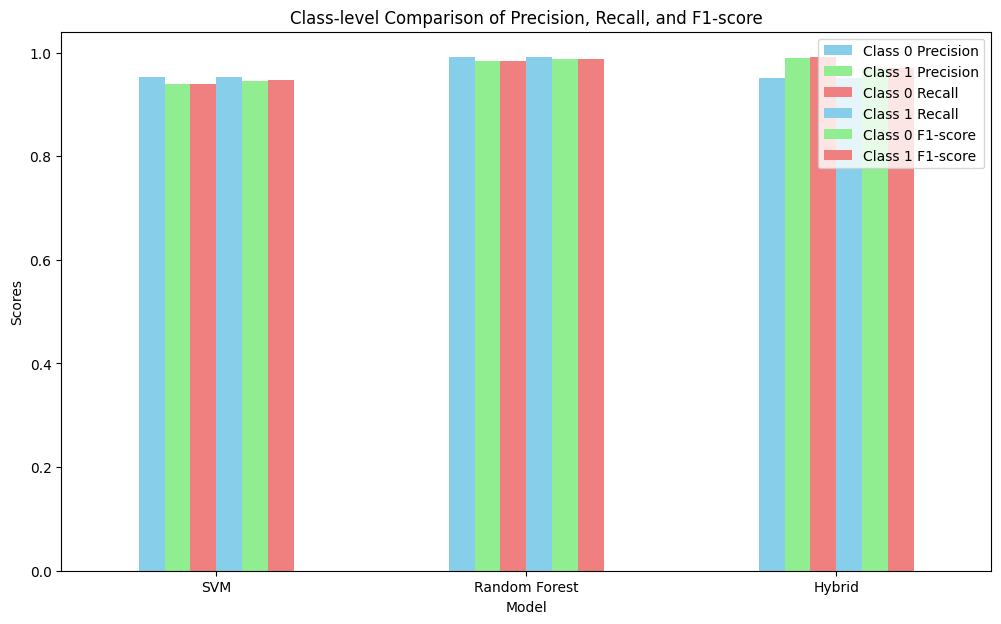

<Figure size 1200x700 with 0 Axes>

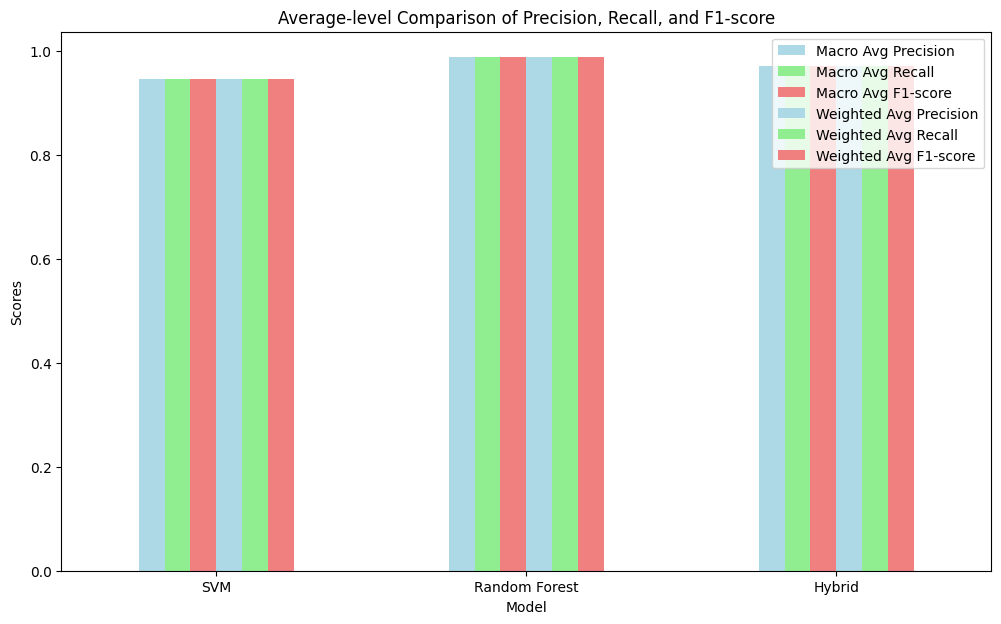

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import pandas as pd

# Assuming svm_pred, rf_pred, and final_pred are already calculated

# Confusion Matrix for SVM
svm_cm = confusion_matrix(y_test, svm_pred)
# Confusion Matrix for Random Forest
rf_cm = confusion_matrix(y_test, rf_pred)
# Confusion Matrix for Hybrid Model
hybrid_cm = confusion_matrix(y_test, final_pred)

# Classification Report for SVM
svm_report = classification_report(y_test, svm_pred, output_dict=True)
# Classification Report for Random Forest
rf_report = classification_report(y_test, rf_pred, output_dict=True)
# Classification Report for Hybrid Model
hybrid_report = classification_report(y_test, final_pred, output_dict=True)

# Visualizing Confusion Matrix for SVM
plt.figure(figsize=(10, 7))
sns.heatmap(svm_cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# Visualizing Confusion Matrix for Random Forest
plt.figure(figsize=(10, 7))
sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# Visualizing Confusion Matrix for Hybrid Model
plt.figure(figsize=(10, 7))
sns.heatmap(hybrid_cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.title("Hybrid Model Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# Function to display classification report as a pandas DataFrame
def print_classification_report(report):
    """
    Converts the classification report dictionary to a pandas DataFrame for better readability.
    """
    # Convert the classification report dictionary into a pandas DataFrame
    report_df = pd.DataFrame(report).T
    
    # If the DataFrame has an 'accuracy' column, drop it for clarity
    if 'accuracy' in report_df.columns:
        report_df.drop(columns=['accuracy'], inplace=True)
    
    return report_df

# Display the classification reports for each model
print("\nSVM Classification Report:")
svm_report_df = print_classification_report(svm_report)
print(svm_report_df)

print("\nRandom Forest Classification Report:")
rf_report_df = print_classification_report(rf_report)
print(rf_report_df)

print("\nHybrid Model Classification Report:")
hybrid_report_df = print_classification_report(hybrid_report)
print(hybrid_report_df)
# Extract metrics (precision, recall, f1-score) for each model
# First, get the metrics for each model (precision, recall, f1-score) and averages (macro avg, weighted avg)
def extract_metrics(report):
    # Extract precision, recall, and f1-score for each class and averages
    class_metrics = {key: report[key] for key in report if key not in ['accuracy', 'macro avg', 'weighted avg']}
    avg_metrics = {key: report[key] for key in ['macro avg', 'weighted avg']}
    
    return class_metrics, avg_metrics

# Extract metrics for each model
svm_class_metrics, svm_avg_metrics = extract_metrics(svm_report)
rf_class_metrics, rf_avg_metrics = extract_metrics(rf_report)
hybrid_class_metrics, hybrid_avg_metrics = extract_metrics(hybrid_report)

# Convert the extracted metrics into a DataFrame for better visualization
# Class-level metrics
class_metrics_df = pd.DataFrame({
    'Model': ['SVM', 'Random Forest', 'Hybrid'],
    'Class 0 Precision': [svm_class_metrics['0']['precision'], rf_class_metrics['0']['precision'], hybrid_class_metrics['0']['precision']],
    'Class 1 Precision': [svm_class_metrics['1']['precision'], rf_class_metrics['1']['precision'], hybrid_class_metrics['1']['precision']],
    'Class 0 Recall': [svm_class_metrics['0']['recall'], rf_class_metrics['0']['recall'], hybrid_class_metrics['0']['recall']],
    'Class 1 Recall': [svm_class_metrics['1']['recall'], rf_class_metrics['1']['recall'], hybrid_class_metrics['1']['recall']],
    'Class 0 F1-score': [svm_class_metrics['0']['f1-score'], rf_class_metrics['0']['f1-score'], hybrid_class_metrics['0']['f1-score']],
    'Class 1 F1-score': [svm_class_metrics['1']['f1-score'], rf_class_metrics['1']['f1-score'], hybrid_class_metrics['1']['f1-score']],
})

# Average-level metrics
avg_metrics_df = pd.DataFrame({
    'Model': ['SVM', 'Random Forest', 'Hybrid'],
    'Macro Avg Precision': [svm_avg_metrics['macro avg']['precision'], rf_avg_metrics['macro avg']['precision'], hybrid_avg_metrics['macro avg']['precision']],
    'Macro Avg Recall': [svm_avg_metrics['macro avg']['recall'], rf_avg_metrics['macro avg']['recall'], hybrid_avg_metrics['macro avg']['recall']],
    'Macro Avg F1-score': [svm_avg_metrics['macro avg']['f1-score'], rf_avg_metrics['macro avg']['f1-score'], hybrid_avg_metrics['macro avg']['f1-score']],
    'Weighted Avg Precision': [svm_avg_metrics['weighted avg']['precision'], rf_avg_metrics['weighted avg']['precision'], hybrid_avg_metrics['weighted avg']['precision']],
    'Weighted Avg Recall': [svm_avg_metrics['weighted avg']['recall'], rf_avg_metrics['weighted avg']['recall'], hybrid_avg_metrics['weighted avg']['recall']],
    'Weighted Avg F1-score': [svm_avg_metrics['weighted avg']['f1-score'], rf_avg_metrics['weighted avg']['f1-score'], hybrid_avg_metrics['weighted avg']['f1-score']],
})

# Barplot for better visualization of classification metrics
plt.figure(figsize=(12, 7))
class_metrics_df.set_index('Model').plot(kind='bar', figsize=(12, 7), color=['skyblue', 'lightgreen', 'lightcoral'])
plt.title('Class-level Comparison of Precision, Recall, and F1-score')
plt.ylabel('Scores')
plt.xticks(rotation=0)
plt.show()

# Barplot for average-level metrics
plt.figure(figsize=(12, 7))
avg_metrics_df.set_index('Model').plot(kind='bar', figsize=(12, 7), color=['lightblue', 'lightgreen', 'lightcoral'])
plt.title('Average-level Comparison of Precision, Recall, and F1-score')
plt.ylabel('Scores')
plt.xticks(rotation=0)
plt.show()


In [16]:
# Save the SVM model and Random Forest model
joblib.dump(svm_model, 'svm_model.pkl')
joblib.dump(rf_model, 'rf_model.pkl')

# Save the final hybrid model if needed
joblib.dump(final_pred, 'hybrid_model.pkl')


['hybrid_model.pkl']

In [19]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
import joblib


# Initialize and fit the scaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Feature selection using SelectKBest with f_classif (ANOVA F-value)
selector = SelectKBest(score_func=f_classif, k=20)
X_new = selector.fit_transform(X_scaled, y)

# Get the top 10 selected features
selected_features = X.columns[selector.get_support()]
print(f"Top 10 Features: {selected_features}")

# Save the scaler and SelectKBest using joblib
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(selector, 'select_k_best.pkl')

# Optionally, you can load them back later like this:
# scaler_loaded = joblib.load('scaler.pkl')
# selector_loaded = joblib.load('select_k_best.pkl')


Top 10 Features: Index(['logged_in', 'count', 'serror_rate', 'srv_serror_rate', 'rerror_rate',
       'srv_rerror_rate', 'same_srv_rate', 'dst_host_count',
       'dst_host_srv_count', 'dst_host_same_srv_rate',
       'dst_host_diff_srv_rate', 'dst_host_serror_rate',
       'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
       'dst_host_srv_rerror_rate', 'service_domain_u', 'service_http',
       'service_private', 'flag_S0', 'flag_SF'],
      dtype='object')


c:\Users\1256\.conda\envs\myenv\lib\site-packages\sklearn\feature_selection\_univariate_selection.py:112: UserWarning: Features [ 6 17 18] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\Users\1256\.conda\envs\myenv\lib\site-packages\sklearn\feature_selection\_univariate_selection.py:113: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


['select_k_best.pkl']

In [ ]:


# Display feature names before feature selection
print("Feature Names before feature selection:")
print(X.columns)

# Feature selection using SelectKBest
selector = SelectKBest(score_func=f_classif, k=20)
X_new = selector.fit_transform(X, y)

# Get the selected features after SelectKBest
selected_features = X.columns[selector.get_support()]

# Display top 20 selected features
print(f"Top 20 Selected Features: {selected_features}")


Feature Names before feature selection:
Index(['id', 'duration', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment',
       'urgent', 'hot', 'num_failed_logins', 'logged_in',
       ...
       'flag_REJ', 'flag_RSTO', 'flag_RSTOS0', 'flag_RSTR', 'flag_S0',
       'flag_S1', 'flag_S2', 'flag_S3', 'flag_SF', 'flag_SH'],
      dtype='object', length=115)
Top 20 Selected Features: Index(['logged_in', 'serror_rate', 'srv_serror_rate', 'same_srv_rate',
       'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_serror_rate',
       'dst_host_srv_serror_rate', 'flag_S0', 'flag_SF'],
      dtype='object')


c:\Users\1256\.conda\envs\myenv\lib\site-packages\sklearn\feature_selection\_univariate_selection.py:112: UserWarning: Features [ 6 17 18] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\Users\1256\.conda\envs\myenv\lib\site-packages\sklearn\feature_selection\_univariate_selection.py:113: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


In [22]:
import pandas as pd
import joblib

# Load the saved scaler and SelectKBest
scaler = joblib.load('scaler.pkl')
selector = joblib.load('select_k_best.pkl')

# Assuming df is your original dataframe (replace with your dataframe)
df_encoded = pd.get_dummies(df, drop_first=True)  # Ensure you apply the same encoding as before

# Apply the scaler to your input features
X_scaled = scaler.transform(X)

# Use SelectKBest to transform the data
X_selected = selector.transform(X_scaled)

# Get the selected feature names based on the transformation
selected_feature_names = X.columns[selector.get_support()]

# Display the selected feature names and count
print(f"Selected Feature Names: {selected_feature_names}")
print(f"Number of Selected Features: {len(selected_feature_names)}")


Selected Feature Names: Index(['logged_in', 'count', 'serror_rate', 'srv_serror_rate', 'rerror_rate',
       'srv_rerror_rate', 'same_srv_rate', 'dst_host_count',
       'dst_host_srv_count', 'dst_host_same_srv_rate',
       'dst_host_diff_srv_rate', 'dst_host_serror_rate',
       'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
       'dst_host_srv_rerror_rate', 'service_domain_u', 'service_http',
       'service_private', 'flag_S0', 'flag_SF'],
      dtype='object')
Number of Selected Features: 20


# 🔮 **Checking Predictions**

In this section, we will evaluate the model’s predictions by providing new input data and checking the output. 

### **Step 1: Input New Data**

You can provide a set of features for which you want to predict the target class.


In [26]:
import pandas as pd
import joblib
from sklearn.preprocessing import LabelEncoder

# Load the saved scaler, SelectKBest, model, and LabelEncoder
scaler = joblib.load('scaler.pkl')
selector = joblib.load('select_k_best.pkl')
model = joblib.load('rf_model.pkl')
label_encoder = joblib.load('label_encoder.pkl')  # Load the LabelEncoder for the target variable

# Check the type of the model you are loading
print(f"Loaded model type: {type(model)}")  # Should print <class 'sklearn.ensemble.RandomForestClassifier'> or other classifier type

# Prepare the input data: create a DataFrame for a single row of data
input_data = {
    'logged_in': [1],  # Example values
    'serror_rate': [0.05],
    'srv_serror_rate': [0.02],
    'same_srv_rate': [0.03],
    'dst_host_srv_count': [1],
    'dst_host_same_srv_rate': [0.2],
    'dst_host_serror_rate': [0.01],
    'dst_host_srv_serror_rate': [0.01],
    'flag_S0': [0],
    'flag_SF': [1]
}

# Convert the input data into a DataFrame
input_df = pd.DataFrame(input_data)

# Ensure the input DataFrame has the same columns as the model training data
input_df_encoded = pd.get_dummies(input_df, drop_first=True)

# Make sure the input data has the same number of columns after encoding
input_df_encoded = input_df_encoded.reindex(columns=scaler.feature_names_in_, fill_value=0)

# Apply the scaler to the input data
input_scaled = scaler.transform(input_df_encoded)

# Apply SelectKBest to the scaled input data
input_selected = selector.transform(input_scaled)

# Ensure input_selected is a 2D array
input_selected = input_selected.reshape(1, -1)  # Reshape to ensure it's 2D

# If the model's target is encoded (i.e., LabelEncoder was used), you can reverse the encoding to get the human-readable label
# In case the model output is categorical, label_encoder will decode it back to its original form
prediction = model.predict(input_selected)

# In case the model uses LabelEncoder, decode the prediction
decoded_prediction = label_encoder.inverse_transform(prediction)

# Display the prediction
print(f"Prediction (encoded): {prediction}")
print(f"Prediction (decoded): {decoded_prediction}")


Loaded model type: <class 'sklearn.ensemble._forest.RandomForestClassifier'>
Prediction (encoded): [1]
Prediction (decoded): ['normal']


# 🤖 **Training and Saving Gradient Boosting and XGBoost Models**

In this section, we train two powerful **ensemble models**:
1. **Gradient Boosting (GB)**: A model that builds an additive model in a forward stage-wise manner by optimizing for loss reduction.
2. **XGBoost (XGB)**: A more regularized and efficient version of gradient boosting, known for its speed and performance in classification tasks.

### **Step 1: Initialize the Models**

First, we initialize the **Gradient Boosting** and **XGBoost** models with a **random seed** to ensure reproducibility.

```python
# Initialize models
gb_model = GradientBoostingClassifier(random_state=42)  # Gradient Boosting Classifier
xgb_model = XGBClassifier(random_state=42)  # XGBoost Classifier


In [28]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
# Initialize models
gb_model = GradientBoostingClassifier(random_state=42)
xgb_model = XGBClassifier(random_state=42)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # Scale training data
X_test_scaled = scaler.transform(X_test)        # Scale test data using same scaler

# Train both models
gb_model.fit(X_train_scaled, y_train)

xgb_model.fit(X_train_scaled, y_train)

# Save the trained models
joblib.dump(gb_model, 'gb_model.pkl')
joblib.dump(xgb_model, 'xgb_model.pkl')


['xgb_model.pkl']

In [29]:
# Predict on the test set using both models
gb_pred = gb_model.predict(X_test_scaled)
xgb_pred = xgb_model.predict(X_test_scaled)

# Print confusion matrix and classification report for Gradient Boosting
print("Gradient Boosting Confusion Matrix:")
print(confusion_matrix(y_test, gb_pred))
print(classification_report(y_test, gb_pred))

# Print confusion matrix and classification report for XGBoost
print("XGBoost Confusion Matrix:")
print(confusion_matrix(y_test, xgb_pred))
print(classification_report(y_test, xgb_pred))

# Calculate Accuracy for both models
gb_accuracy = accuracy_score(y_test, gb_pred)
xgb_accuracy = accuracy_score(y_test, xgb_pred)

print(f"Gradient Boosting Accuracy: {gb_accuracy}")
print(f"XGBoost Accuracy: {xgb_accuracy}")


Gradient Boosting Confusion Matrix:
[[1809   52]
 [  15 1850]]
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      1861
           1       0.97      0.99      0.98      1865

    accuracy                           0.98      3726
   macro avg       0.98      0.98      0.98      3726
weighted avg       0.98      0.98      0.98      3726

XGBoost Confusion Matrix:
[[1835   26]
 [  15 1850]]
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1861
           1       0.99      0.99      0.99      1865

    accuracy                           0.99      3726
   macro avg       0.99      0.99      0.99      3726
weighted avg       0.99      0.99      0.99      3726

Gradient Boosting Accuracy: 0.9820182501341922
XGBoost Accuracy: 0.988996242619431


Gradient Boosting Accuracy: 0.9820182501341922
XGBoost Accuracy: 0.988996242619431
Gradient Boosting Confusion Matrix:
[[1809   52]
 [  15 1850]]
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      1861
           1       0.97      0.99      0.98      1865

    accuracy                           0.98      3726
   macro avg       0.98      0.98      0.98      3726
weighted avg       0.98      0.98      0.98      3726

XGBoost Confusion Matrix:
[[1835   26]
 [  15 1850]]
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1861
           1       0.99      0.99      0.99      1865

    accuracy                           0.99      3726
   macro avg       0.99      0.99      0.99      3726
weighted avg       0.99      0.99      0.99      3726



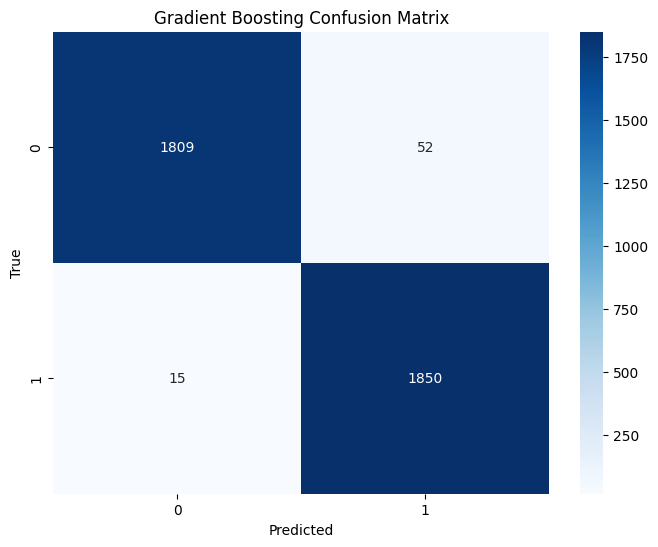

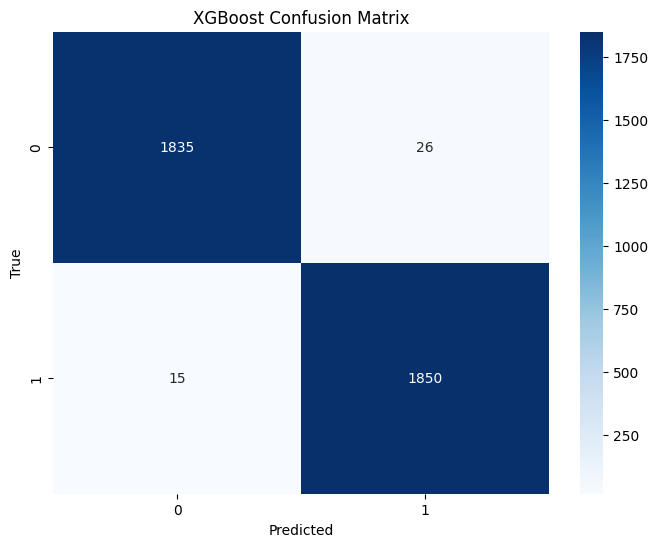

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import numpy as np

# Assuming gb_pred, xgb_pred, and y_test are already defined

# Predict on the test set using both models
gb_pred = gb_model.predict(X_test_scaled)
xgb_pred = xgb_model.predict(X_test_scaled)

# Calculate Accuracy for both models
gb_accuracy = accuracy_score(y_test, gb_pred)
xgb_accuracy = accuracy_score(y_test, xgb_pred)

# Print accuracy
print(f"Gradient Boosting Accuracy: {gb_accuracy}")
print(f"XGBoost Accuracy: {xgb_accuracy}")

# Print confusion matrix and classification report for Gradient Boosting
print("Gradient Boosting Confusion Matrix:")
print(confusion_matrix(y_test, gb_pred))
print(classification_report(y_test, gb_pred))

# Print confusion matrix and classification report for XGBoost
print("XGBoost Confusion Matrix:")
print(confusion_matrix(y_test, xgb_pred))
print(classification_report(y_test, xgb_pred))

# Function to plot confusion matrix using Seaborn
def plot_confusion_matrix(cm, model_name):
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
    plt.title(f'{model_name} Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

# Confusion Matrix for Gradient Boosting
gb_cm = confusion_matrix(y_test, gb_pred)
plot_confusion_matrix(gb_cm, "Gradient Boosting")

# Confusion Matrix for XGBoost
xgb_cm = confusion_matrix(y_test, xgb_pred)
plot_confusion_matrix(xgb_cm, "XGBoost")


In [31]:
# Combine predictions from both models by averaging (for hybrid model)
final_pred = (gb_pred + xgb_pred) // 2

# Print the confusion matrix and classification report for the hybrid model
print("Hybrid Model (Averaged GB + XGB) Confusion Matrix:")
print(confusion_matrix(y_test, final_pred))
print(classification_report(y_test, final_pred))

# Calculate accuracy for the hybrid model
hybrid_accuracy = accuracy_score(y_test, final_pred)
print(f"Hybrid Model Accuracy: {hybrid_accuracy}")


Hybrid Model (Averaged GB + XGB) Confusion Matrix:
[[1840   21]
 [  23 1842]]
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1861
           1       0.99      0.99      0.99      1865

    accuracy                           0.99      3726
   macro avg       0.99      0.99      0.99      3726
weighted avg       0.99      0.99      0.99      3726

Hybrid Model Accuracy: 0.988191089640365


In [32]:
# Save the hybrid model predictions (if you want to save the results)
joblib.dump(final_pred, 'hybrid_model_predictions.pkl')

# Save the final hybrid model (average predictions from both models)
joblib.dump(final_pred, 'gb_hybrid_model.pkl')


['gb_hybrid_model.pkl']

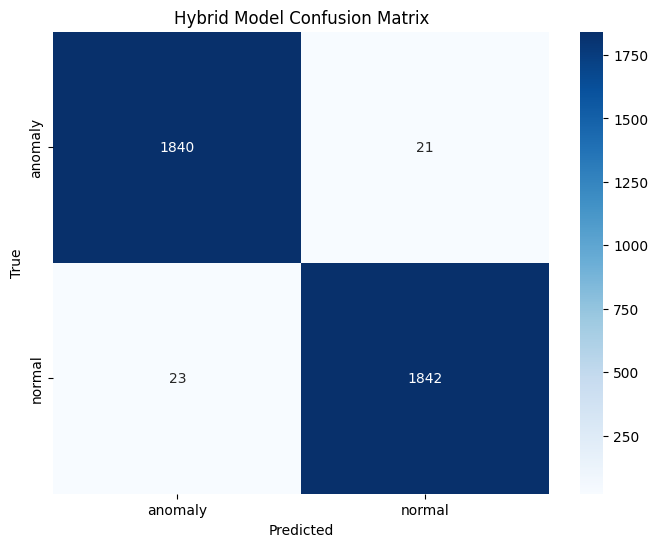

Hybrid Model (Averaged GB + XGB) Confusion Matrix:
[[1840   21]
 [  23 1842]]
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1861
           1       0.99      0.99      0.99      1865

    accuracy                           0.99      3726
   macro avg       0.99      0.99      0.99      3726
weighted avg       0.99      0.99      0.99      3726

Hybrid Model Accuracy: 0.988191089640365


In [33]:
# Plot confusion matrix for the hybrid model
cm = confusion_matrix(y_test, final_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Hybrid Model Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()
# Combine predictions from both models by averaging (for hybrid model)
final_pred = (gb_pred + xgb_pred) // 2

# Print the confusion matrix and classification report for the hybrid model
print("Hybrid Model (Averaged GB + XGB) Confusion Matrix:")
print(confusion_matrix(y_test, final_pred))
print(classification_report(y_test, final_pred))

# Calculate accuracy for the hybrid model
hybrid_accuracy = accuracy_score(y_test, final_pred)
print(f"Hybrid Model Accuracy: {hybrid_accuracy}")


# 🔄 **Stacking Classifier: Combining Logistic Regression and K-Nearest Neighbors**

In this section, we train a **Stacking Classifier** that combines two base models:
1. **Logistic Regression (LR)**
2. **K-Nearest Neighbors (KNN)**

The **meta-model** (final estimator) used in this stacking classifier is **Logistic Regression**.

### **Step 1: Initialize the Base Models**

We start by initializing the base models (**Logistic Regression** and **K-Nearest Neighbors**) with their respective parameters. These models will be trained independently on the data, and their outputs will be used by the meta-model.

```python
# Initialize base models
lr_model = LogisticRegression(random_state=42)  # Logistic Regression model
knn_model = KNeighborsClassifier(n_neighbors=5)  # K-Nearest Neighbors model


In [34]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.ensemble import StackingClassifier
from sklearn.base import BaseEstimator, ClassifierMixin
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize base models
lr_model = LogisticRegression(random_state=42)
knn_model = KNeighborsClassifier(n_neighbors=5)

# Initialize Stacking Classifier with Logistic Regression as the meta-model
stacking_model = StackingClassifier(
    estimators=[('lr', lr_model), ('knn', knn_model)], 
    final_estimator=LogisticRegression()
)

# Train the stacking model
stacking_model.fit(X_train_scaled, y_train)

# Save the trained stacking model
joblib.dump(stacking_model, 'stacking_model.pkl')


['stacking_model.pkl']

Logistic Regression Confusion Matrix:
[[1749  112]
 [  84 1781]]
              precision    recall  f1-score   support

           0       0.95      0.94      0.95      1861
           1       0.94      0.95      0.95      1865

    accuracy                           0.95      3726
   macro avg       0.95      0.95      0.95      3726
weighted avg       0.95      0.95      0.95      3726

KNN Confusion Matrix:
[[1825   36]
 [  23 1842]]
              precision    recall  f1-score   support

           0       0.99      0.98      0.98      1861
           1       0.98      0.99      0.98      1865

    accuracy                           0.98      3726
   macro avg       0.98      0.98      0.98      3726
weighted avg       0.98      0.98      0.98      3726

Stacking Model Confusion Matrix:
[[1831   30]
 [  24 1841]]
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      1861
           1       0.98      0.99      0.99      1865

    accu

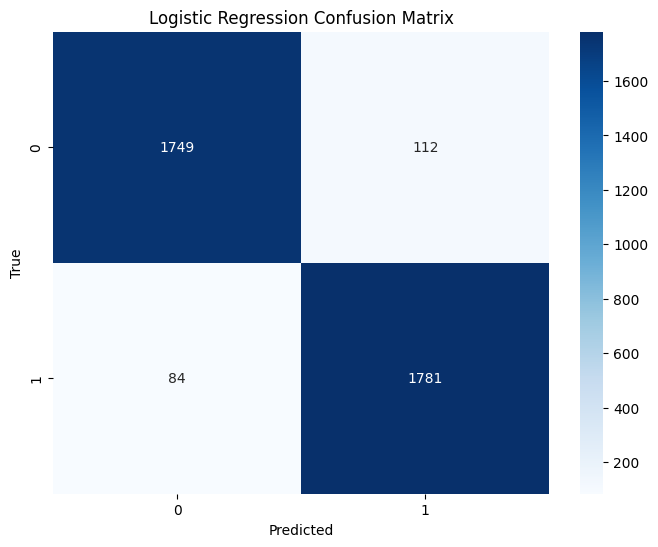

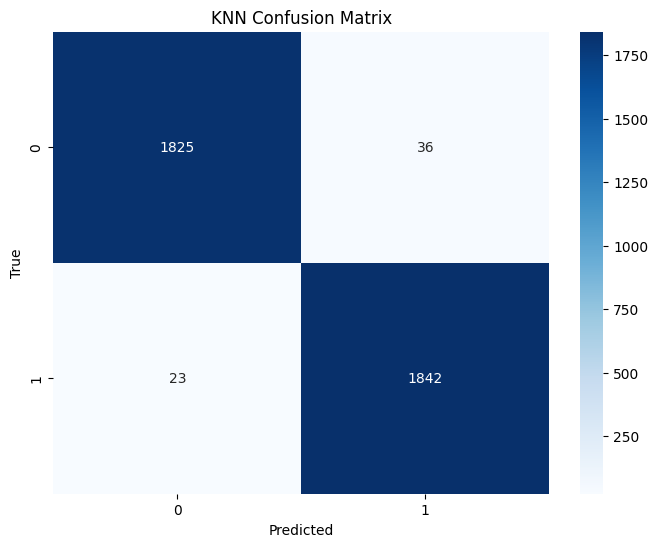

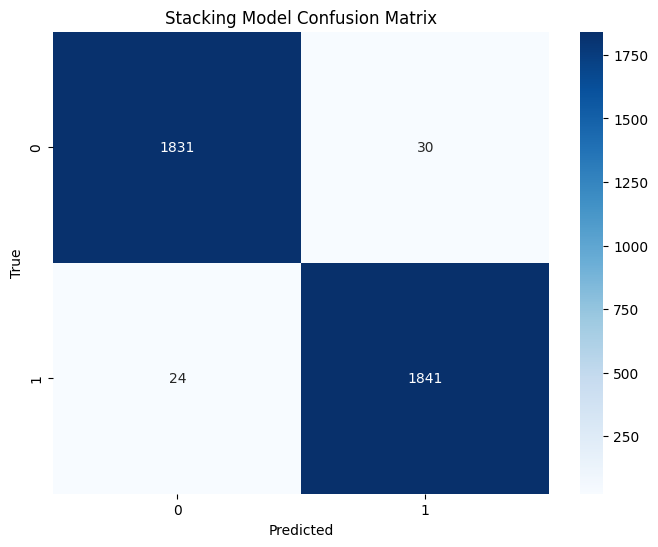

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import joblib

# Initialize base models
lr_model = LogisticRegression(random_state=42)
knn_model = KNeighborsClassifier(n_neighbors=5)

# Train both base models on the scaled training data
lr_model.fit(X_train_scaled, y_train)
knn_model.fit(X_train_scaled, y_train)

# Now, train the stacking model
stacking_model = StackingClassifier(
    estimators=[('lr', lr_model), ('knn', knn_model)], 
    final_estimator=LogisticRegression()
)

# Fit the stacking model on the training data
stacking_model.fit(X_train_scaled, y_train)

# Save the trained stacking model
joblib.dump(stacking_model, 'stacking_model.pkl')

# Predict on the test set using the base models (now that they are trained)
lr_pred = lr_model.predict(X_test_scaled)
knn_pred = knn_model.predict(X_test_scaled)

# Predict using the stacking model (this is the final combined prediction)
stacking_pred = stacking_model.predict(X_test_scaled)

# Print confusion matrix and classification report for Logistic Regression
print("Logistic Regression Confusion Matrix:")
print(confusion_matrix(y_test, lr_pred))
print(classification_report(y_test, lr_pred))

# Print confusion matrix and classification report for KNN
print("KNN Confusion Matrix:")
print(confusion_matrix(y_test, knn_pred))
print(classification_report(y_test, knn_pred))

# Print confusion matrix and classification report for Stacking Model
print("Stacking Model Confusion Matrix:")
print(confusion_matrix(y_test, stacking_pred))
print(classification_report(y_test, stacking_pred))

# Calculate Accuracy for all models
lr_accuracy = accuracy_score(y_test, lr_pred)
knn_accuracy = accuracy_score(y_test, knn_pred)
stacking_accuracy = accuracy_score(y_test, stacking_pred)

print(f"Logistic Regression Accuracy: {lr_accuracy}")
print(f"KNN Accuracy: {knn_accuracy}")
print(f"Stacking Model Accuracy: {stacking_accuracy}")

# Function to plot confusion matrix using Seaborn
def plot_confusion_matrix(cm, model_name):
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
    plt.title(f'{model_name} Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

# Confusion Matrix for Logistic Regression
lr_cm = confusion_matrix(y_test, lr_pred)
plot_confusion_matrix(lr_cm, "Logistic Regression")

# Confusion Matrix for KNN
knn_cm = confusion_matrix(y_test, knn_pred)
plot_confusion_matrix(knn_cm, "KNN")

# Confusion Matrix for Stacking Model
stacking_cm = confusion_matrix(y_test, stacking_pred)
plot_confusion_matrix(stacking_cm, "Stacking Model")


In [36]:
import joblib

# Save the base models (Logistic Regression and KNN)
joblib.dump(lr_model, 'lr_model.pkl')  # Save Logistic Regression model
joblib.dump(knn_model, 'knn_model.pkl')  # Save KNN model

# Save the stacking model (which includes both base models and meta-model)
joblib.dump(stacking_model, 'stacking_model.pkl')  # Save the stacking model


['stacking_model.pkl']

# 📊 **Performance Comparison of Hybrid Models**

In this section, we compare the performance of different hybrid models based on their **accuracy** scores. We use a **bar chart** to visually compare the performance of the following hybrid models:

1. **Hybrid SVM-RF**
2. **Hybrid LR-KNN**
3. **Hybrid GB-XGB**

### **Step 1: Model Accuracy**

We have compu

C:\Users\1256\AppData\Local\Temp\ipykernel_10808\3406309167.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Accuracy', y='Model', data=model_performance, palette='viridis')


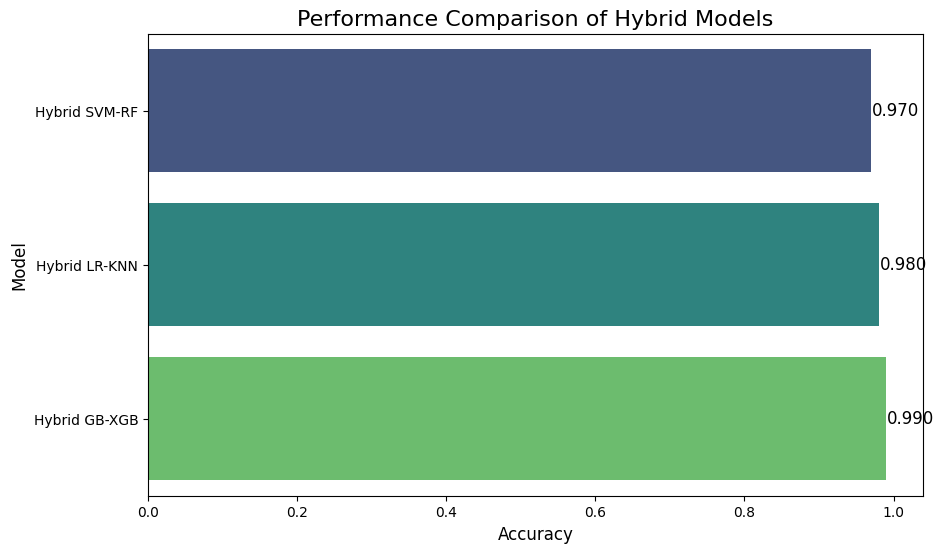

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Store the model names and their corresponding accuracy scores
models = ['Hybrid SVM-RF', 'Hybrid LR-KNN', 'Hybrid GB-XGB']
accuracies = [0.97, 0.98, 0.99]  # Replace these values with the actual accuracies of your models

# Create a DataFrame for visualization
model_performance = pd.DataFrame({
    'Model': models,
    'Accuracy': accuracies
})

# Plot the bar chart
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Accuracy', y='Model', data=model_performance, palette='viridis')

# Add accuracy values on top of the bars
for p in ax.patches:
    ax.annotate(f'{p.get_width():.3f}',  # Display the accuracy value (rounded to 3 decimals)
                (p.get_width() + 0.001, p.get_y() + p.get_height() / 2),  # Positioning the text
                ha='left', va='center', fontsize=12, color='black')

# Title and labels
plt.title('Performance Comparison of Hybrid Models', fontsize=16)
plt.xlabel('Accuracy', fontsize=12)
plt.ylabel('Model', fontsize=12)

# Display the plot
plt.show()
